# Load Constitution Files

In [ ]:
from google.colab import files
import numpy as np
import pandas as pd

In [ ]:
uploaded = files.upload()

Saving Hawaii1978_final_parts_0.txt to Hawaii1978_final_parts_0.txt
Saving NY1894_final_parts_0.txt to NY1894_final_parts_0.txt
Saving FL1838%20_final_parts_0.txt to FL1838%20_final_parts_0.txt
Saving WV1861_final_parts_0.txt to WV1861_final_parts_0.txt
Saving MI1835_final_parts_0.txt to MI1835_final_parts_0.txt
Saving SC1790_final_parts_0.txt to SC1790_final_parts_0.txt
Saving OK1907_amd1_final_parts.txt to OK1907_amd1_final_parts.txt
Saving FL1861_final_parts_0.txt to FL1861_final_parts_0.txt
Saving MD1867_amd1_final_parts_0.txt to MD1867_amd1_final_parts_0.txt
Saving AL1901_final_parts_0.txt to AL1901_final_parts_0.txt
Saving MI1962_amd_final_parts_0.txt to MI1962_amd_final_parts_0.txt
Saving AL1875_final_parts_0.txt to AL1875_final_parts_0.txt
Saving DE1831_final_parts_0.txt to DE1831_final_parts_0.txt
Saving NH1776_final_parts_0.txt to NH1776_final_parts_0.txt
Saving LA1868_final_parts_0.txt to LA1868_final_parts_0.txt
Saving PA1874_final_parts_0.txt to PA1874_final_parts_0.txt
Sa

In [ ]:
import os
import shutil

# 1. Create the 'constitutions' folder if it doesn't exist
if not os.path.exists('constitutions'):
    os.makedirs('constitutions')


# 2. Loop through the uploaded files and move them to the folder
for filename in uploaded.keys():
    # Define source (current directory) and destination (constitutions folder)
    src_path = filename
    dst_path = os.path.join('constitutions', filename)

    # Move the file
    shutil.move(src_path, dst_path)
    print(f"Moved {filename} to 'constitutions/' folder.")

print("\nAll files uploaded and organized successfully.")


Moved Hawaii1978_final_parts_0.txt to 'constitutions/' folder.
Moved NY1894_final_parts_0.txt to 'constitutions/' folder.
Moved FL1838%20_final_parts_0.txt to 'constitutions/' folder.
Moved WV1861_final_parts_0.txt to 'constitutions/' folder.
Moved MI1835_final_parts_0.txt to 'constitutions/' folder.
Moved SC1790_final_parts_0.txt to 'constitutions/' folder.
Moved OK1907_amd1_final_parts.txt to 'constitutions/' folder.
Moved FL1861_final_parts_0.txt to 'constitutions/' folder.
Moved MD1867_amd1_final_parts_0.txt to 'constitutions/' folder.
Moved AL1901_final_parts_0.txt to 'constitutions/' folder.
Moved MI1962_amd_final_parts_0.txt to 'constitutions/' folder.
Moved AL1875_final_parts_0.txt to 'constitutions/' folder.
Moved DE1831_final_parts_0.txt to 'constitutions/' folder.
Moved NH1776_final_parts_0.txt to 'constitutions/' folder.
Moved LA1868_final_parts_0.txt to 'constitutions/' folder.
Moved PA1874_final_parts_0.txt to 'constitutions/' folder.
Moved MD1851_final_parts_0.txt to 'co

In [ ]:
import re

# 1. SETUP: State Abbreviation Dictionary
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# 2. Extract Year
def extract_year_from_filename(filename):
    clean_name = filename.replace('.txt', '').strip().replace('%20', ' ')
    clean_name = re.sub(r'\s*\(\d+\)$', '', clean_name)
    state_codes = '|'.join(re.escape(k) for k in state_abbreviations.keys())
    state_names = '|'.join(re.escape(v) for v in state_abbreviations.values())
    state_pattern = f"(?:{state_codes}|{state_names})"
    year_regex = r"(?i:" + state_pattern + r")\s*?(1[6789]\d{2}|20\d{2})"
    match = re.search(year_regex, clean_name)
    if match: return int(match.group(1))
    fallback_match = re.search(r'(1[6789]\d{2}|20\d{2})', clean_name)
    if fallback_match: return int(fallback_match.group(0))
    return None

# 3. Clean State
def get_clean_state_name(filename):
    filename = filename.strip()
    if filename.lower().endswith('.txt'): filename = filename[:-4]
    filename = filename.replace('%20', ' ')
    filename = re.sub(r'\s\(\d+\)$', '', filename)
    if filename.lower().startswith('wash'): return "Washington"
    if len(filename) >= 2:
        code = filename[:2].upper()
        if code in state_abbreviations: return state_abbreviations[code]
    clean_upper = filename.upper()
    for full_name in state_abbreviations.values():
        if clean_upper.startswith(full_name.upper()): return full_name
    return None

# 4. LOAD DATA
folder_path = 'constitutions'
data = []
for filename in os.listdir(folder_path):
    state_name = get_clean_state_name(filename)
    if state_name:
        year = extract_year_from_filename(filename)
        file_path = os.path.join(folder_path, filename)
        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
            data.append({'State': state_name, 'Text': text, 'Year': year, 'Original_Filename': filename})
        except Exception as e:
            print(f"Error reading {filename}: {e}")

df = pd.DataFrame(data)
df['State'] = df['State'].str.strip()

# 5. MAP REGIONS
state_to_region = {
    'Alabama': 'South', 'Alaska': 'West', 'Arizona': 'West', 'Arkansas': 'South',
    'California': 'West', 'Colorado': 'West', 'Connecticut': 'Northeast', 'Delaware': 'South',
    'Florida': 'South', 'Georgia': 'South', 'Hawaii': 'West', 'Idaho': 'West',
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Iowa': 'Midwest', 'Kansas': 'Midwest',
    'Kentucky': 'South', 'Louisiana': 'South', 'Maine': 'Northeast', 'Maryland': 'South',
    'Massachusetts': 'Northeast', 'Michigan': 'Midwest', 'Minnesota': 'Midwest', 'Mississippi': 'South',
    'Missouri': 'Midwest', 'Montana': 'West', 'Nebraska': 'Midwest', 'Nevada': 'West',
    'New Hampshire': 'Northeast', 'New Jersey': 'Northeast', 'New Mexico': 'West', 'New York': 'Northeast',
    'North Carolina': 'South', 'North Dakota': 'Midwest', 'Ohio': 'Midwest', 'Oklahoma': 'South',
    'Oregon': 'West', 'Pennsylvania': 'Northeast', 'Rhode Island': 'Northeast', 'South Carolina': 'South',
    'South Dakota': 'Midwest', 'Tennessee': 'South', 'Texas': 'South', 'Utah': 'West',
    'Vermont': 'Northeast', 'Virginia': 'South', 'Washington': 'West', 'West Virginia': 'South',
    'Wisconsin': 'Midwest', 'Wyoming': 'West'
}
df['Region'] = df['State'].map(state_to_region)

# Add a unique Label for the Matrix (e.g. 'Arkansas 1868')
df['Label'] = df['State'] + " " + df['Year'].astype(str).str.replace('\\.0', '', regex=True)

print(f"Loaded {len(df)} state constitutions.")
display(df[['Label', 'State', 'Year', 'Region']].head())


Loaded 144 state constitutions.


,Label,State,Year,Region
0,Louisiana 1868,Louisiana,1868,South
1,Mississippi 1817,Mississippi,1817,South
2,Louisiana 1812,Louisiana,1812,South
3,South Carolina 1896,South Carolina,1896,South
4,Florida 1865,Florida,1865,South


## There are multiple versions of constitutions from the same state and year


In [ ]:
# 1. Identify which State/Year combinations have multiple files
dup_counts = df.groupby(['State', 'Year']).size().reset_index(name='Count')
multiple_versions = dup_counts[dup_counts['Count'] > 1]

print(f"Found {len(multiple_versions)} State/Year combinations with multiple files:\n")
display(multiple_versions)

# Let's look at a specific example (e.g., Alabama 1901)
alabama_1901 = df[(df['State'] == 'Alabama') & (df['Year'] == 1901)]
display(alabama_1901[['State', 'Year', 'Original_Filename']])


Found 20 State/Year combinations with multiple files:



,State,Year,Count
5,Alabama,1901,4
12,Colorado,1876,3
38,Iowa,1857,2
39,Kansas,1859,2
43,Kentucky,1890,2
50,Maine,1819,2
54,Maryland,1867,4
56,Michigan,1850,2
57,Michigan,1908,3
58,Michigan,1962,2


,State,Year,Original_Filename
60,Alabama,1901,AL1901_001200_final_parts_0.txt
67,Alabama,1901,AL1901_final_parts_0.txt
91,Alabama,1901,AL1901_401658_final_parts_0.txt
117,Alabama,1901,AL1901_201400_final_parts_0.txt


In [ ]:
# Analyze duplicate State/Year groups to decide on Drop vs. Merge

print("Analyzing multiple versions for the same State and Year:\n")

for index, row in multiple_versions.iterrows():
    state = row['State']
    year = row['Year']

    # Get all rows for this state and year
    group = df[(df['State'] == state) & (df['Year'] == year)]

    print(f"=== {state} {year} ({len(group)} files) ===")

    for _, g_row in group.iterrows():
        filename = g_row['Original_Filename']
        text_length = len(g_row['Text'].split()) # Rough word count
        print(f"  - File: {filename:<35} | Word Count: {text_length:,}")

    # Basic heuristic check
    lengths = [len(text.split()) for text in group['Text']]
    max_len = max(lengths)
    min_len = min(lengths)

    if max_len > 0 and (min_len / max_len) > 0.8:
        print("  -> Suggestion: Likely REDUNDANT copies (similar lengths). Consider keeping the longest one.")
    else:
        print("  -> Suggestion: Likely SPLIT PARTS or AMENDMENTS (different lengths). Consider merging.")
    print("-" * 60)


Analyzing multiple versions for the same State and Year:

=== Alabama 1901 (4 files) ===
  - File: AL1901_001200_final_parts_0.txt     | Word Count: 79,175
  - File: AL1901_final_parts_0.txt            | Word Count: 31,903
  - File: AL1901_401658_final_parts_0.txt     | Word Count: 112,204
  - File: AL1901_201400_final_parts_0.txt     | Word Count: 91,883
  -> Suggestion: Likely SPLIT PARTS or AMENDMENTS (different lengths). Consider merging.
------------------------------------------------------------
=== Colorado 1876 (3 files) ===
  - File: CO1876_amd_final_parts_0.txt        | Word Count: 92,340
  - File: CO1876_amd_final_parts.txt          | Word Count: 92,340
  - File: CO1876_final_parts_0.txt            | Word Count: 23,934
  -> Suggestion: Likely SPLIT PARTS or AMENDMENTS (different lengths). Consider merging.
------------------------------------------------------------
=== Iowa 1857 (2 files) ===
  - File: IA1857_final_parts_0.txt            | Word Count: 12,744
  - File: IA18

In [ ]:
# Merge duplicate files by concatenating their text
print(f"Original row count: {len(df)}")

# Group by State, Year, Region, and Label. We use dropna=False to keep any potential rows without years.
df_merged = df.groupby(['State', 'Year', 'Region', 'Label'], dropna=False).agg({
    'Text': lambda texts: '\n\n*** NEXT PART/AMENDMENT ***\n\n'.join(texts),
    'Original_Filename': lambda names: ' + '.join(names)
}).reset_index()

# Overwrite the original dataframe with the merged one
df = df_merged.copy()

print(f"New row count after merging duplicates: {len(df)}\n")

# Verify by checking Alabama 1901 (which previously had 4 parts)
display(df[(df['State'] == 'Alabama') & (df['Year'] == 1901)][['State', 'Year', 'Original_Filename']])


Original row count: 144
New row count after merging duplicates: 113



,State,Year,Original_Filename
5,Alabama,1901,AL1901_001200_final_parts_0.txt + AL1901_final...


In [ ]:
# Verify the merge for all states that had multiple files
# We can find them by looking for the ' + ' separator we added to the filenames
merged_rows = df[df['Original_Filename'].str.contains(r' \+ ', na=False)]

print(f"Found {len(merged_rows)} merged state constitutions:\n")
display(merged_rows[['State', 'Year', 'Original_Filename']])


Found 20 merged state constitutions:



,State,Year,Original_Filename
5,Alabama,1901,AL1901_001200_final_parts_0.txt + AL1901_final...
12,Colorado,1876,CO1876_amd_final_parts_0.txt + CO1876_amd_fina...
38,Iowa,1857,IA1857_final_parts_0.txt + IA1857_amd_final_pa...
39,Kansas,1859,KS1859_final_parts_0.txt + KS1859_amd_final_pa...
43,Kentucky,1890,KY1890_final_parts_0.txt + Ky1890amd_final_par...
50,Maine,1819,ME1819_amd_final_parts_0.txt + ME1819_final_pa...
54,Maryland,1867,MD1867_amd2_final_parts_0.txt + MD1867_final_p...
56,Michigan,1850,MI1850_final_parts_0.txt + MI1850_amd_final_pa...
57,Michigan,1908,MI1908_final_parts_A.txt + MI1908_final_parts_...
58,Michigan,1962,MI1962_final_parts_0.txt + MI1962_amd_final_pa...


# Create the Cosine Similarity Matrices



In [ ]:
import spacy

# Load the model (heavier, but smarter)
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# Increase max_length to handle longer texts
nlp.max_length = 2000000  # Set to a value greater than the longest text (1,754,247 in this case)

def spacy_lemmatize(text):
    doc = nlp(text)
    # Return the lemma if it's not a stopword, punctuation, or whitespace
    return " ".join([token.lemma_ for token in doc
                     if not token.is_stop and not token.is_punct and not token.is_space])

# Apply to your dataframe
df['Clean_Text'] = df['Text'].apply(spacy_lemmatize)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# 1. Initialize the Vectorizer
# We remove 'english' stop words (common words that add no meaning)
vectorizer = TfidfVectorizer(stop_words='english')

# 2. Create the Matrix (Vectors)
tfidf_matrix = vectorizer.fit_transform(df['Text'])

# 3. Compute Cosine Similarity
# This compares every document against every other document
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Similarity Matrix Shape:", cosine_sim.shape)

Similarity Matrix Shape: (113, 113)


In [ ]:
# Convert the similarity matrix into a DataFrame for readability using the unique 'Label' we created
similarity_df = pd.DataFrame(cosine_sim, index=df['Label'], columns=df['Label'])

# Example: View the top 5 documents most similar to Arkansas 1868
target_key = 'Arkansas'

# Check if the exact key exists; if not, look for a match
if target_key not in similarity_df.columns:
    # Find columns that contain the target_key
    matches = [col for col in similarity_df.columns if target_key in col]
    if matches:
        target_state = matches[0]
        print(f"Key '{target_key}' not found. Using '{target_state}' instead.")
    else:
        target_state = similarity_df.columns[0]
        print(f"Key '{target_key}' not found. Defaulting to '{target_state}'.")
else:
    target_state = target_key

print(f"Constitutions most similar to {target_state}:")
print(similarity_df[target_state].sort_values(ascending=False)[1:11])


Key 'Arkansas' not found. Using 'Arkansas 1864' instead.
Constitutions most similar to Arkansas 1864:
Label
Arkansas 1868     0.752822
Arkansas 1874     0.625500
Maryland 1864     0.541071
Louisiana 1864    0.537151
Nevada 1864       0.480269
Colorado 1876     0.382647
New York 1894     0.366787
Indiana 1851      0.348926
Maine 1819        0.348459
New York 1938     0.346248
Name: Arkansas 1864, dtype: float64


In [ ]:
# 1. Create the DataFrame using the clean Labels
matrix_table = pd.DataFrame(cosine_sim, index=df['Label'], columns=df['Label']).round(2)

# 2. Save to CSV
matrix_table.to_csv('similarity_matrix_full.csv')

# 3. Download the file to your computer
files.download('similarity_matrix_full.csv')

print("Full matrix downloaded.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Full matrix downloaded.


In [ ]:
matrix_table.head()

Label,Alabama 1819,Alabama 1861,Alabama 1865,Alabama 1868,Alabama 1875,Alabama 1901,Alaska 1836,Alaska 1959,Arizona 1912,Arkansas 1864,...,South Dakota 1889,Texas 1845,Texas 1866,Texas 1869,Texas 1876,Utah 1895,Washington 1889,West Virginia 1861,West Virginia 1872,Wyoming 1889
Label,,,,,,,,,,,,,,,,,,,,,
Alabama 1819,1.00,0.62,0.62,0.61,0.64,0.41,0.18,0.19,0.28,0.30,...,0.27,0.28,0.29,0.28,0.25,0.24,0.30,0.24,0.29,0.26
Alabama 1861,0.62,1.00,0.74,0.74,0.70,0.46,0.19,0.24,0.32,0.28,...,0.26,0.26,0.28,0.27,0.27,0.23,0.31,0.23,0.31,0.26
Alabama 1865,0.62,0.74,1.00,0.74,0.70,0.46,0.20,0.25,0.34,0.30,...,0.27,0.27,0.29,0.28,0.28,0.25,0.33,0.24,0.33,0.28
Alabama 1868,0.61,0.74,0.74,1.00,0.71,0.46,0.19,0.24,0.33,0.29,...,0.26,0.26,0.28,0.27,0.27,0.24,0.32,0.23,0.32,0.27
Alabama 1875,0.64,0.70,0.70,0.71,1.00,0.46,0.19,0.22,0.31,0.32,...,0.30,0.30,0.32,0.31,0.29,0.28,0.33,0.26,0.32,0.29


# Time Plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(f"Total loaded: {len(df)}")
print("\nYear Range:")
print(df['Year'].min(), "-", df['Year'].max())
print("\nSample Data:")
display(df[['State', 'Year', 'Region']].head())


Total loaded: 113

Year Range:
1662 - 1986

Sample Data:


,State,Year,Region
0,Alabama,1819,South
1,Alabama,1861,South
2,Alabama,1865,South
3,Alabama,1868,South
4,Alabama,1875,South


In [ ]:
df.head()


,State,Year,Region,Label,Text,Original_Filename,Clean_Text
0,Alabama,1819,South,Alabama 1819,This is ready to go\n\nJW 12.29.01 ...,AL1819_final_parts_0.txt,ready JW 12.29.01 CONSTITUTION 1819 text CSTAR...
1,Alabama,1861,South,Alabama 1861,This is ready to go\n\nJW 12/29/01\n ...,AL1861_final_parts_0.txt,ready JW 12/29/01 CSTART AL 1/7/1861 9/12/1865...
2,Alabama,1865,South,Alabama 1865,This is ready to go.\n\nJW 12.29.01\n\n ...,AL1865_final_parts_0.txt,ready JW 12.29.01 CONSTITUTION 1865 text CSTAR...
3,Alabama,1868,South,Alabama 1868,This one is ready to go.\nJW 12.29.01 ...,AL1868_final_parts_0.txt,ready JW 12.29.01 CONSTITUTION 1868 text CSTAR...
4,Alabama,1875,South,Alabama 1875,This constitution is ready to go.\nJW 12.29.01...,AL1875_final_parts_0.txt,constitution ready JW 12.29.01 CONSTITUTION 18...


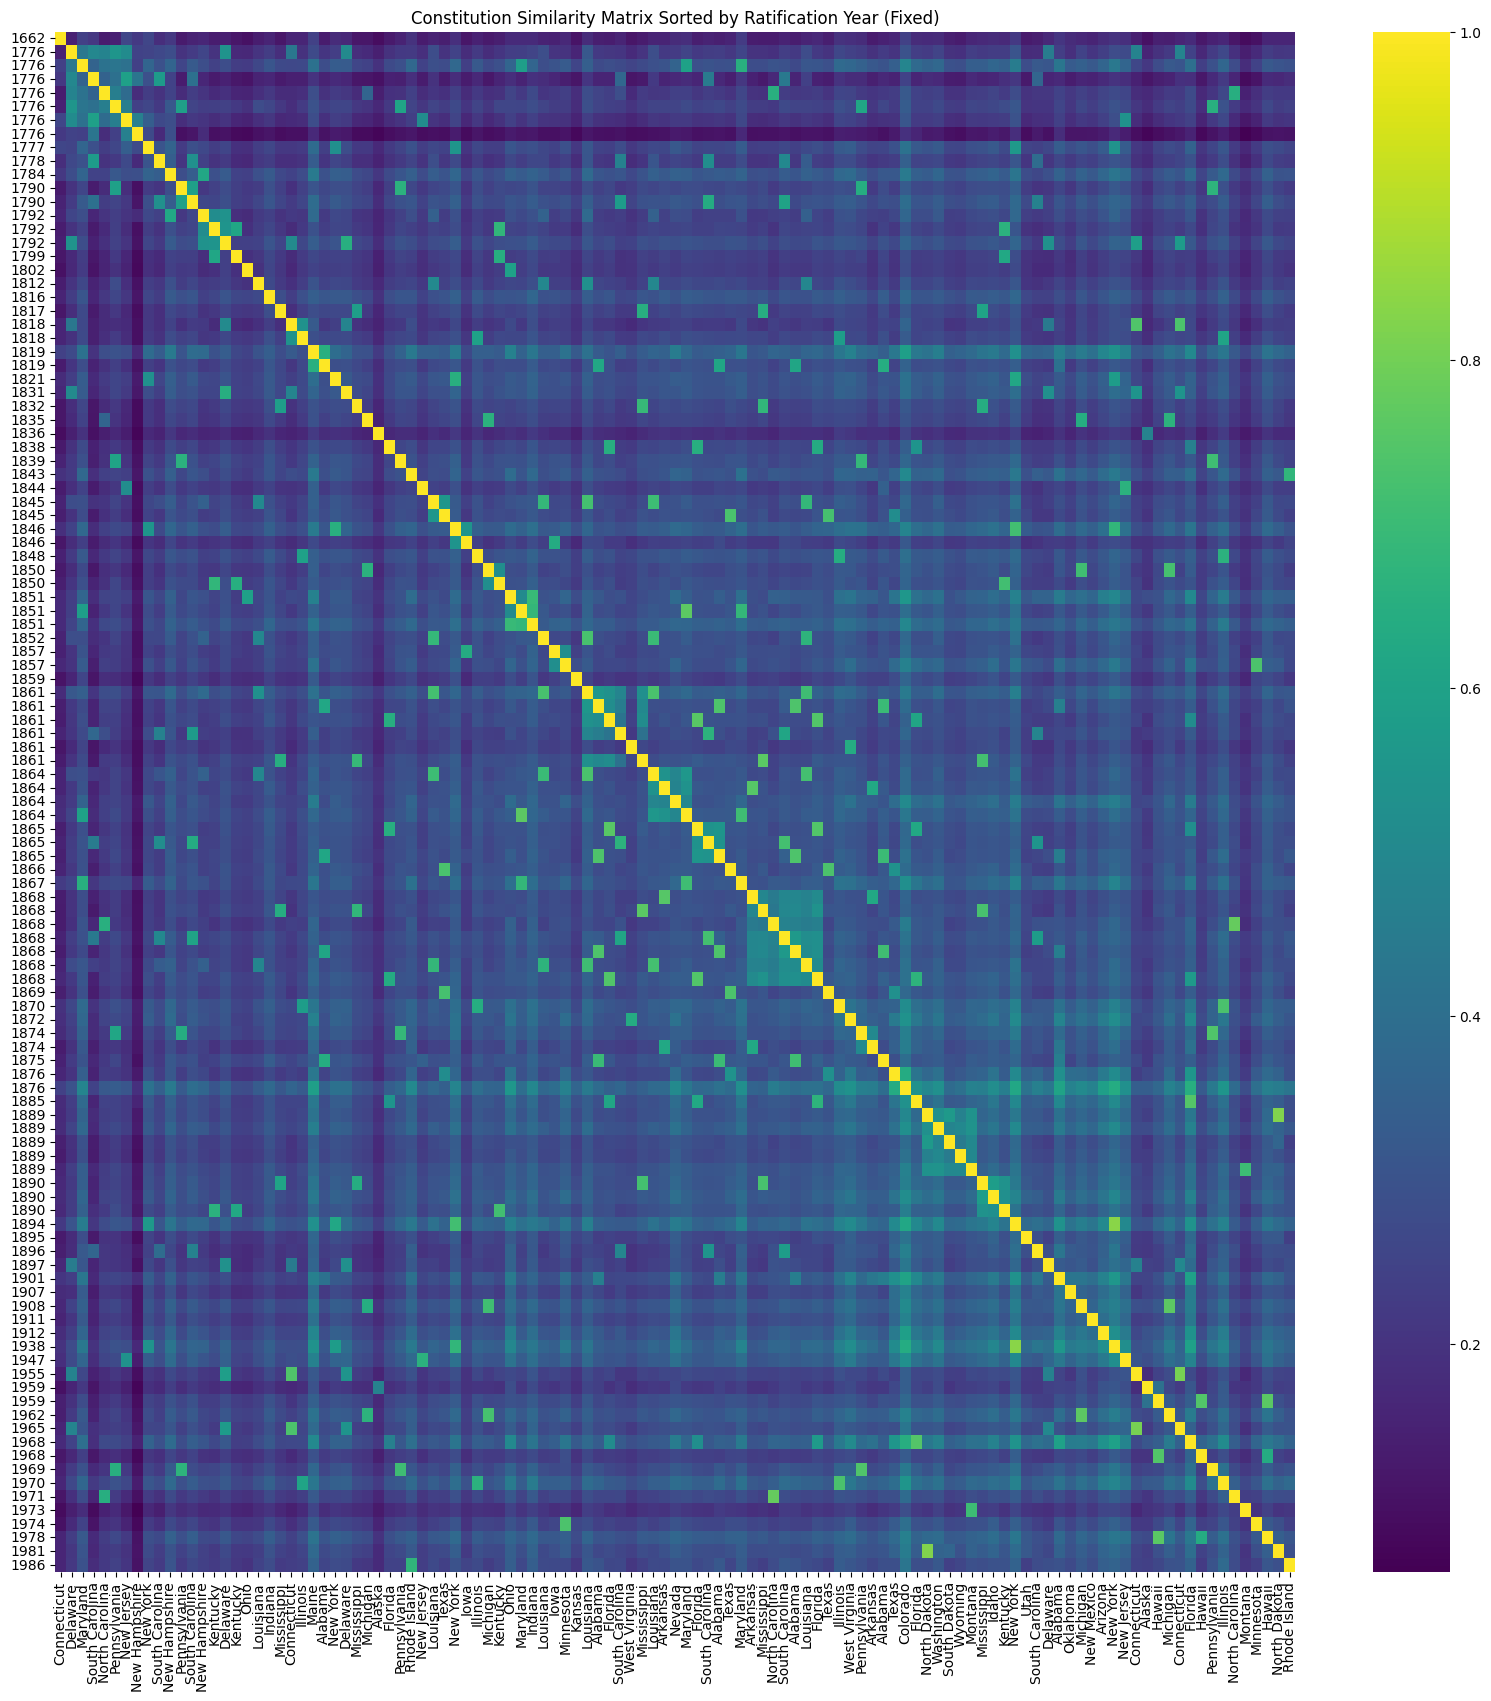

In [ ]:
# Re-run the plotting preparation with the fixed years
df_plot = df.dropna(subset=['Year']).copy()
df_plot = df_plot.sort_values('Year')

sorted_indices = df_plot.index.values
cosine_sim_sorted = cosine_sim[np.ix_(sorted_indices, sorted_indices)]

# Now re-plot the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(cosine_sim_sorted,
            xticklabels=df_plot['State'],
            yticklabels=df_plot['Year'],
            cmap="viridis",
            linewidths=0)
plt.title('Constitution Similarity Matrix Sorted by Ratification Year (Fixed)')
plt.show()


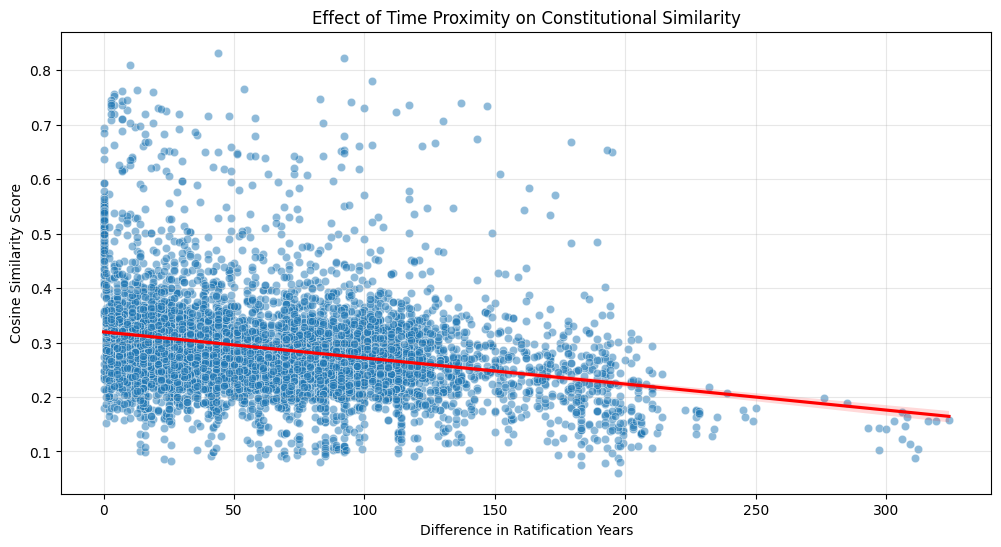


Correlation Coefficient: -0.2670
Result: Negative Correlation. Constitutions written closer together in time tend to be more similar.


In [ ]:
# Prepare data for pairwise comparison
data_pairs = []

# Loop through every unique pair
# Note: This loops over the filtered dataframe (with valid years)
for i in range(len(df_plot)):
    for j in range(i + 1, len(df_plot)):
        state_i = df_plot.iloc[i]['State']
        state_j = df_plot.iloc[j]['State']

        year_i = df_plot.iloc[i]['Year']
        year_j = df_plot.iloc[j]['Year']

        # Calculate absolute difference in years
        year_diff = abs(int(year_i) - int(year_j))

        # Get similarity score from the SORTED matrix
        # We need to map the current index 'i' and 'j' back to the sorted matrix indices
        # Since df_plot is sorted, the positional index 'i' corresponds to the sorted matrix row 'i'
        sim_score = cosine_sim_sorted[i][j]

        data_pairs.append({
            'Year_Difference': year_diff,
            'Similarity': sim_score,
            'State_Pair': f"{state_i} vs {state_j}"
        })

pair_df = pd.DataFrame(data_pairs)

# Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Year_Difference', y='Similarity', data=pair_df, alpha=0.5)

# Add a trend line
sns.regplot(x='Year_Difference', y='Similarity', data=pair_df, scatter=False, color='red')

plt.title('Effect of Time Proximity on Constitutional Similarity')
plt.xlabel('Difference in Ratification Years')
plt.ylabel('Cosine Similarity Score')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate Correlation
correlation = pair_df['Year_Difference'].corr(pair_df['Similarity'])
print(f"\nCorrelation Coefficient: {correlation:.4f}")

if correlation < -0.1:
    print("Result: Negative Correlation. Constitutions written closer together in time tend to be more similar.")
elif correlation > 0.1:
    print("Result: Positive Correlation. Older constitutions are surprisingly similar to newer ones.")
else:
    print("Result: No Correlation. Time does not appear to affect similarity.")

In [ ]:
import scipy.stats as stats

# 1. Prepare the Data (You might need to re-run the 'pair_df' creation code from earlier)
# pair_df should have columns 'Year_Difference' and 'Similarity'
# If you don't have pair_df loaded, run the loop that creates it first.

# 2. Calculate Pearson Correlation and P-Value
# Null Hypothesis: There is no relationship between Year Difference and Similarity.
# Alternative Hypothesis: There is a relationship.
corr, p_value = stats.pearsonr(pair_df['Year_Difference'], pair_df['Similarity'])

print(f"Correlation Coefficient (r): {corr:.4f}")
print(f"P-Value: {p_value:.4e}")

# 3. Interpretation
if p_value < 0.05:
    print("\nResult: The correlation is STATISTICALLY SIGNIFICANT.")
    print("We reject the null hypothesis. Time has a real effect on similarity.")
else:
    print("\nResult: Not significant. The trend might be random chance.")

Correlation Coefficient (r): -0.2670
P-Value: 8.9843e-104

Result: The correlation is STATISTICALLY SIGNIFICANT.
We reject the null hypothesis. Time has a real effect on similarity.


In [ ]:
# Save the cleaned dataframe (with State, Text, Year, Region) to a CSV
df.to_csv('clean_constitutions.csv', index=False)

# Download it to your computer (so you can upload it to the new notebook)
from google.colab import files
files.download('clean_constitutions.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Region Plot

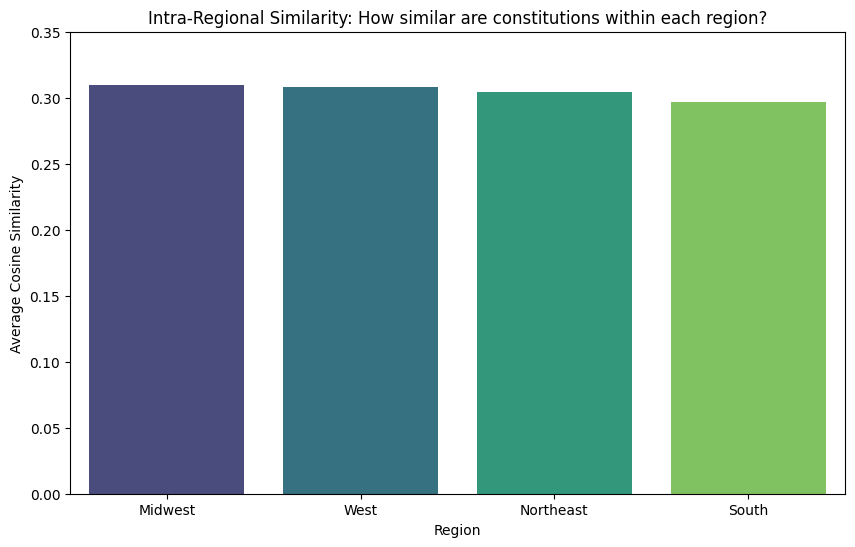

In [ ]:
# 1. Calculate Average Similarity for each Region
region_similarities = []

for region in df['Region'].unique():
    # Get the indices of states in this region
    region_indices = df[df['Region'] == region].index.tolist()

    # Extract the sub-matrix for just these states
    # This assumes 'cosine_sim' is aligned with your df (indices match)
    sub_matrix = cosine_sim[np.ix_(region_indices, region_indices)]

    # Fill diagonal with 0 to ignore self-similarity (always 1.0)
    np.fill_diagonal(sub_matrix, 0)

    # Calculate average score
    avg_score = sub_matrix.mean()

    region_similarities.append({'Region': region, 'Avg_Similarity': avg_score})

# 2. Create DataFrame for plotting
region_df = pd.DataFrame(region_similarities).sort_values('Avg_Similarity', ascending=False)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Avg_Similarity', data=region_df, palette='viridis', hue='Region', legend=False)
plt.title('Intra-Regional Similarity: How similar are constitutions within each region?')
plt.ylabel('Average Cosine Similarity')
plt.ylim(0, 0.35) # Similarity is always 0 to 1
plt.show()


# Potential Thesis Proposals

## The "Topic Modeling" Project (Clustering)

### The Question: If I group the constitutions by topic (Problem Areas), which states fall into which group?

* X (Input): The text of the constitution.
* Y (Output/Cluster): A hidden topic (e.g., "Taxation Focus", "Civil Liberties Focus", "Environmental Focus").

Instead of comparing State A to State B, you compare Sections of the Constitution. This helps you find "Problems" (topics heavily discussed) vs "Solutions" (amendments addressing those topics).

How to do it (using LDA - Latent Dirichlet Allocation):
This algorithm reads all texts and guesses, say, 5 main topics that exist across all states.



In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# 1. Use the same vectorizer from before (TF-IDF or CountVectorizer)
# LDA works best with raw counts, so let's use CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words='english')
dtm = cv.fit_transform(df['Text'])

# 2. Fit LDA Model (Look for 5 distinct topics)
LDA = LatentDirichletAllocation(n_components=5, random_state=42)
LDA.fit(dtm)

# 3. Print the top words for each topic
for index, topic in enumerate(LDA.components_):
    print(f"\nTOPIC #{index+1}")
    print([cv.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

# You might see Topic 0 is "tax, revenue, dollar, levy" -> Economic Focus
# You might see Topic 1 is "school, teacher, university" -> Education Focus


TOPIC #1
['mstart', 'bonds', 'property', 'law', 'provided', 'general', 'county', 'section', 'state', 'shall']

TOPIC #2
['election', 'provided', 'section', 'county', 'sstart', 'send', 'law', 'sec', 'state', 'shall']

TOPIC #3
['office', 'governor', 'law', 'assembly', 'general', 'sec', 'state', 'sstart', 'send', 'shall']

TOPIC #4
['district', 'provided', 'article', 'legislature', 'law', 'court', 'county', 'section', 'state', 'shall']

TOPIC #5
['legislature', 'election', 'provided', 'said', 'bonds', 'state', 'tax', 'amendment', 'county', 'shall']


# Baker Questions

* Look at how one state's constitution is similar to itself over time
* Look at how similar all constitutions are when available for a particular window - for example, 1776 constitutions, 1861 constitutions, etc. etc.
* The idea is to see how they evolved over time.
* Can we also get a sense as to what the topics looked like over time and across places simultaneously? (Move this to **Topic Modeling** notebook)

---




#

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- ASSUMPTION ---
# Your dataframe 'df' has columns: 'State', 'Year', 'Text'
# And multiple rows for states that changed over time.

# 1. Filter out states that only have ONE constitution version
# (You can't compare a state to itself over time if it only has one version)
state_counts = df['State'].value_counts()
valid_states = state_counts[state_counts > 1].index.tolist()
df_multi = df[df['State'].isin(valid_states)].copy()

# 2. GLOBAL VECTORIZATION (Do this OUTSIDE the loop!)
print("Vectorizing all documents globally...")
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_multi['Text'])

# 3. Create an empty dictionary to hold all your State DataFrames
state_similarity_dfs = {}

print("Calculating intra-state similarities...")
# 4. Loop through the dataframe grouped by State
for state_name, group in df_multi.groupby('State'):

    # Get the original integer index locations for this specific state
    # This was the problematic line. group.index contains the original indices from df.
    # tfidf_matrix is indexed by the *position* of the rows in df_multi.
    # We need to map the original indices to their 0-based positions within df_multi.
    positional_indices_for_group = [df_multi.index.get_loc(idx) for idx in group.index]

    # Slice the global TF-IDF matrix to get ONLY this state's vectors
    state_vectors = tfidf_matrix[positional_indices_for_group]

    # Calculate cosine similarity (Comparing State Year A to State Year B)
    state_cosine_sim = cosine_similarity(state_vectors)

    # Create a DataFrame for readability
    # We use the actual 'Year' as the index and column names so it's easy to read
    years = group['Year'].tolist()
    state_sim_df = pd.DataFrame(state_cosine_sim, index=years, columns=years)

    # Optional: Add a column showing the average similarity to past versions
    # state_sim_df['Avg_Similarity_To_Past'] = state_sim_df.mean(axis=1)

    # Save to our dictionary
    state_similarity_dfs[state_name] = state_sim_df

print("Done! DataFrames created for all states.")

Vectorizing all documents globally...
Calculating intra-state similarities...
Done! DataFrames created for all states.


## State Similarity

In [ ]:
import os
import shutil
from google.colab import files

# View Alabama's similarity to itself over time
print("Alabama's similarity over time:")
print(state_similarity_dfs['Alabama'])

# Create a directory to store the state CSV files
output_dir_state = 'state_similarity_matrices'
os.makedirs(output_dir_state, exist_ok=True)

# Loop through the dictionary and save each matrix
for state_name, sim_df in state_similarity_dfs.items():
    filename = os.path.join(output_dir_state, f"{state_name}_self_similarity.csv")
    sim_df.to_csv(filename)

# Zip the directory
shutil.make_archive(output_dir_state, 'zip', output_dir_state)

# Download the zip file
zip_filename_state = f"{output_dir_state}.zip"
files.download(zip_filename_state)

print(f"\nSuccessfully zipped and downloaded {len(state_similarity_dfs)} state matrices as {zip_filename_state}.")

Alabama's similarity over time:
          1819      1861      1865      1868      1875      1901
1819  1.000000  0.614886  0.613832  0.608139  0.635742  0.399579
1861  0.614886  1.000000  0.742298  0.738795  0.699419  0.456351
1865  0.613832  0.742298  1.000000  0.744515  0.705829  0.452612
1868  0.608139  0.738795  0.744515  1.000000  0.711410  0.453327
1875  0.635742  0.699419  0.705829  0.711410  1.000000  0.454745
1901  0.399579  0.456351  0.452612  0.453327  0.454745  1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Successfully zipped and downloaded 28 state matrices as state_similarity_matrices.zip.


## Time Similarity

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Filter out years that only have ONE constitution drafted
year_counts = df['Year'].value_counts()
valid_years = year_counts[year_counts > 1].index.tolist()
df_multi_year = df[df['Year'].isin(valid_years)].copy()

# 2. Global Vectorization for these valid documents
print("Vectorizing documents globally...")
vectorizer_time = TfidfVectorizer(stop_words='english')
tfidf_matrix_time = vectorizer_time.fit_transform(df_multi_year['Text'])

# 3. Create a dictionary to hold all your Year DataFrames
year_similarity_dfs = {}

print("Calculating similarities for constitutions drafted in the same year...")
# 4. Loop through the dataframe grouped by Year
for year, group in df_multi_year.groupby('Year'):
    # Get positional indices for this specific year
    positional_indices = [df_multi_year.index.get_loc(idx) for idx in group.index]

    # Slice the matrix for only this year's vectors
    year_vectors = tfidf_matrix_time[positional_indices]

    # Calculate cosine similarity (State A vs State B within the same year)
    year_cosine_sim = cosine_similarity(year_vectors)

    # Create a DataFrame for readability using State names as index/columns
    states = group['State'].tolist()
    year_sim_df = pd.DataFrame(year_cosine_sim, index=states, columns=states)

    year_similarity_dfs[year] = year_sim_df

print(f"Done! Created comparison matrices for {len(year_similarity_dfs)} different years.\n")

# Let's look at an example: Constitutions drafted in 1868 (Reconstruction Era)
example_year = 1868
if example_year in year_similarity_dfs:
    print(f"Similarity Matrix for states drafting constitutions in {example_year}:")
    display(year_similarity_dfs[example_year].round(3))
else:
    print(f"No multiple constitutions found for the year {example_year}.")


Vectorizing documents globally...
Calculating similarities for constitutions drafted in the same year...
Done! Created comparison matrices for 20 different years.

Similarity Matrix for states drafting constitutions in 1868:


,Alabama,Arkansas,Florida,Louisiana,Mississippi,North Carolina,South Carolina
Alabama,1.000,0.488,0.512,0.493,0.471,0.453,0.563
Arkansas,0.488,1.000,0.514,0.473,0.484,0.446,0.503
Florida,0.512,0.514,1.000,0.506,0.521,0.462,0.529
Louisiana,0.493,0.473,0.506,1.000,0.457,0.447,0.515
Mississippi,0.471,0.484,0.521,0.457,1.000,0.418,0.483
North Carolina,0.453,0.446,0.462,0.447,0.418,1.000,0.476
South Carolina,0.563,0.503,0.529,0.515,0.483,0.476,1.000


In [ ]:
import os
import shutil
from google.colab import files

# Create a directory to store the CSV files
output_dir = 'year_similarity_matrices'
os.makedirs(output_dir, exist_ok=True)

# Loop through the dictionary and save each matrix
for year, sim_df in year_similarity_dfs.items():
    filename = os.path.join(output_dir, f"similarity_matrix_{year}.csv")
    sim_df.to_csv(filename)

# Zip the directory
shutil.make_archive(output_dir, 'zip', output_dir)

# Download the zip file
zip_filename = f"{output_dir}.zip"
files.download(zip_filename)

print(f"Successfully zipped and downloaded {len(year_similarity_dfs)} matrices as {zip_filename}.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully zipped and downloaded 20 matrices as year_similarity_matrices.zip.


## Evolution over time

### Visualizing Constitutional Evolution (Task 3)
Let's visualize how a specific state's constitution evolved over time by looking at a heatmap of its changes, and a trend line tracking its similarity to its original constitution.

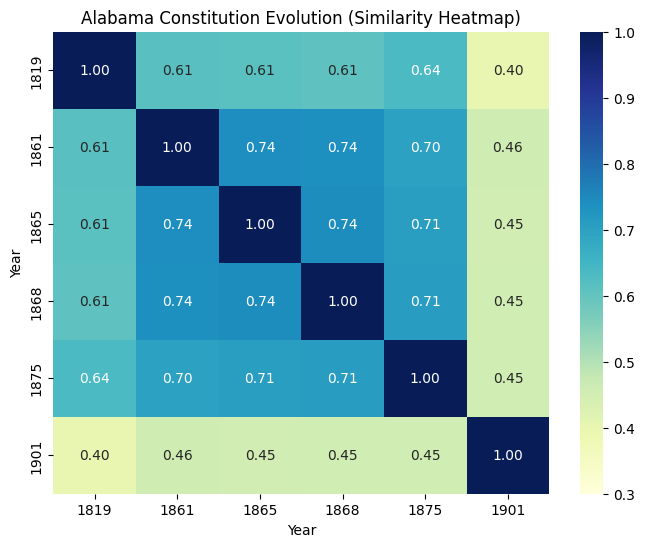

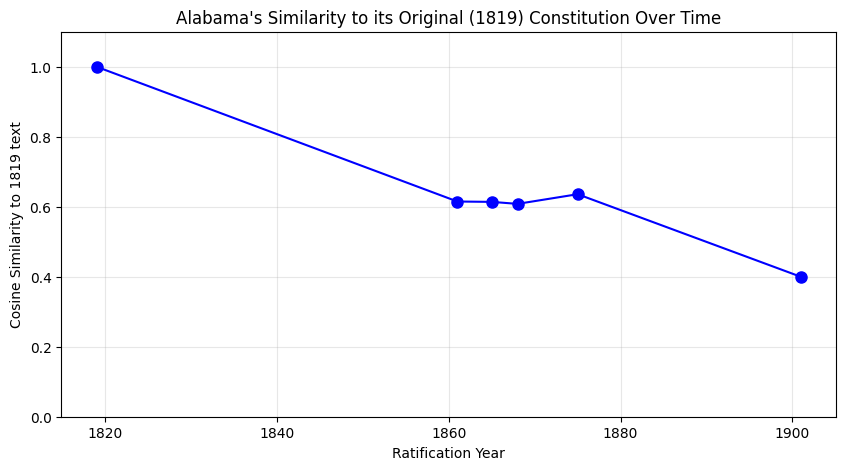

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a state with multiple constitutions to visualize
state_to_plot = 'Alabama'

if state_to_plot in state_similarity_dfs:
    sim_df = state_similarity_dfs[state_to_plot]

    # 1. Heatmap of the state's evolution
    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_df, annot=True, cmap="YlGnBu", vmin=0.3, vmax=1.0, fmt=".2f")
    plt.title(f"{state_to_plot} Constitution Evolution (Similarity Heatmap)")
    plt.xlabel("Year")
    plt.ylabel("Year")
    plt.show()

    # 2. Line plot: Similarity to the FIRST constitution over time
    first_year = sim_df.index[0]
    evolution_series = sim_df.loc[first_year]

    plt.figure(figsize=(10, 5))
    plt.plot(evolution_series.index, evolution_series.values, marker='o', linestyle='-', color='b', markersize=8)
    plt.title(f"{state_to_plot}'s Similarity to its Original ({first_year}) Constitution Over Time")
    plt.xlabel("Ratification Year")
    plt.ylabel(f"Cosine Similarity to {first_year} text")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Could not find {state_to_plot} in the dataset.")

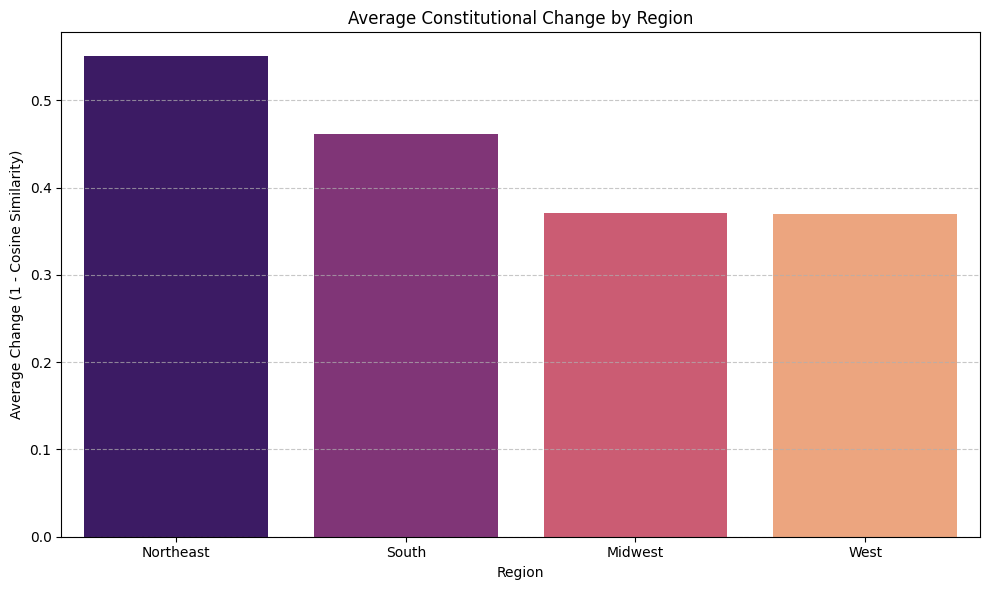

,Region,Change
1,Northeast,0.550
2,South,0.462
0,Midwest,0.370
3,West,0.370


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import linregress # New import

# Ensure 'df' and 'state_similarity_dfs' are available
if 'df' in locals() and 'state_similarity_dfs' in locals():

    # Re-create decline_df within this cell (copied from c3ccc021)
    decline_rates = []
    for state, sim_df in state_similarity_dfs.items():
        first_year = sim_df.index[0]
        evolution_series = sim_df.loc[first_year]

        years_since_first = [year - first_year for year in evolution_series.index]
        similarities = evolution_series.values

        # Calculate the slope (rate of change) using linear regression
        slope, intercept, r_value, p_value, std_err = linregress(years_since_first, similarities)

        decline_rates.append({
            'State': state,
            'Slope (Decline/Year)': slope,
            'Decline per Decade': slope * 10,
            'Total Drop': 1.0 - similarities[-1],
            'Years Span': years_since_first[-1]
        })

    decline_df = pd.DataFrame(decline_rates)
    decline_df = decline_df.sort_values(by='Slope (Decline/Year)', ascending=True).reset_index(drop=True)

    # Use decline_df as the source for changes, assuming 'Total Drop' is the desired change metric
    # Create a 'Change' column in decline_df for merging
    decline_df['Change'] = decline_df['Total Drop']

    changes_df_with_region = pd.merge(
        decline_df,
        df[['State', 'Region']].drop_duplicates(),
        on='State',
        how='left'
    )

    # Calculate average change per region
    change_per_region = changes_df_with_region.groupby('Region')['Change'].mean().reset_index()
    change_per_region = change_per_region.sort_values(by='Change', ascending=False)

    # Plotting the change per region
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Region', y='Change', data=change_per_region, palette='magma', hue='Region', legend=False)
    plt.title('Average Constitutional Change by Region')
    plt.xlabel('Region')
    plt.ylabel('Average Change (1 - Cosine Similarity)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    display(change_per_region.round(3))
else:
    print("Error: 'df' or 'state_similarity_dfs' DataFrame not found. Please ensure the data loading and cleaning cells have been executed.")

In [ ]:
# Export the exact text the TF-IDF model needs
export_for_regression = df[['State', 'Year', 'Region', 'Clean_Text']]
export_for_regression.to_csv('regression_ready_data.csv', index=False)

# Optionally download the file immediately
files.download('regression_ready_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Summary Statistics

## Table 1

In [ ]:
import pandas as pd
import numpy as np
import os

# Load data if df is not in memory
if 'df' not in locals():
    df = pd.read_csv('regression_ready_data.csv')

# 1. Ensure Word Count and Era columns exist
df['Word_Count'] = df['Clean_Text'].apply(lambda x: len(str(x).split()))
df['Era'] = df['Year'].apply(lambda x: 'Pre-1865' if x < 1865 else 'Post-1865')

# 2. Collect Data with Categories as Rows
categories = ['Overall', 'Pre-1865', 'Post-1865'] + sorted(df['Region'].dropna().unique().tolist())

table_data = {'Category': [], 'Word Count': []}

for cat in categories:
    if cat == 'Overall':
        group = df
    elif cat in ['Pre-1865', 'Post-1865']:
        group = df[df['Era'] == cat]
    else:
        group = df[df['Region'] == cat]

    mean_val = group['Word_Count'].mean()
    std_val = group['Word_Count'].std()

    # Add the mean
    table_data['Category'].append(cat)
    table_data['Word Count'].append(f"{mean_val:,.0f}")

    # Add the standard deviation in the row immediately underneath
    table_data['Category'].append("")
    table_data['Word Count'].append(f"({std_val:,.0f})")

# Add the single Total Observations row at the bottom
table_data['Category'].append('Total Observations')
table_data['Word Count'].append(f"{len(df)}")

summary_df = pd.DataFrame(table_data).set_index('Category')

# 3. Format for "Published Research Paper" Look
styles = [
    dict(selector="table", props=[("font-family", "'Times New Roman', Times, serif"),
                                  ("border-collapse", "collapse"),
                                  ("margin", "20px 0")]),
    dict(selector="th", props=[("border-top", "2px solid black"),
                               ("border-bottom", "1px solid black"),
                               ("text-align", "center"),
                               ("padding", "8px 15px"),
                               ("font-size", "11pt"),
                               ("font-weight", "bold")]),
    dict(selector="th.row_heading", props=[("border-top", "none"),
                                           ("border-bottom", "none"),
                                           ("text-align", "left"),
                                           ("font-size", "11pt"),
                                           ("font-weight", "normal"),
                                           ("padding", "6px 15px")]),
    dict(selector="td", props=[("text-align", "center"),
                               ("padding", "6px 15px"),
                               ("font-size", "11pt")]),
    dict(selector="tr:last-child td", props=[("border-bottom", "2px solid black")]),
    dict(selector="tr:last-child th", props=[("border-bottom", "2px solid black")]),
    dict(selector="caption", props=[("caption-side", "top"),
                                    ("text-align", "left"),
                                    ("font-size", "12pt"),
                                    ("font-weight", "bold"),
                                    ("color", "black"),
                                    ("padding-bottom", "10px")])
]

# Apply the styling
styled_table = (summary_df.style
                .set_table_styles(styles)
                .set_caption("Table 1. Summary Statistics of State Constitutions by Era and Region"))

display(styled_table)


,Word Count
Category,
Overall,"18,069"
,"(25,952)"
Pre-1865,"8,345"
,"(7,985)"
Post-1865,"28,324"
,"(33,480)"
Midwest,"15,342"
,"(11,282)"
Northeast,"12,832"


In [ ]:
from google.colab import files

# Save the raw data to CSV
csv_filename = 'summary_statistics.csv'
summary_df.to_csv(csv_filename)

# Save the styled table to LaTeX for professional publication
latex_filename = 'summary_statistics.tex'
with open(latex_filename, 'w') as f:
    f.write(styled_table.to_latex())

# Download both files
files.download(csv_filename)
files.download(latex_filename)

print(f"Successfully exported {csv_filename} and {latex_filename}!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully exported summary_statistics.csv and summary_statistics.tex!


# Baker questions May 26 2026

 I was wondering if you could somehow construct graphs for some cases:
  * can you describe similarity over time for one state?
  * Can we identify time periods in which constitutions changed more rapidly? Maybe we could develop a measure that shows "change per decade" or "change per region."

So we basically already did the first task for Alabama. Baker would prefer if we used year 0 as a base point rather than 1819.

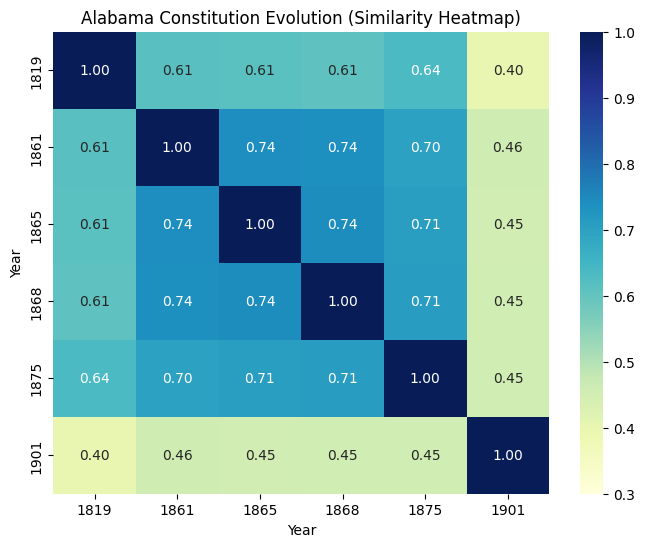

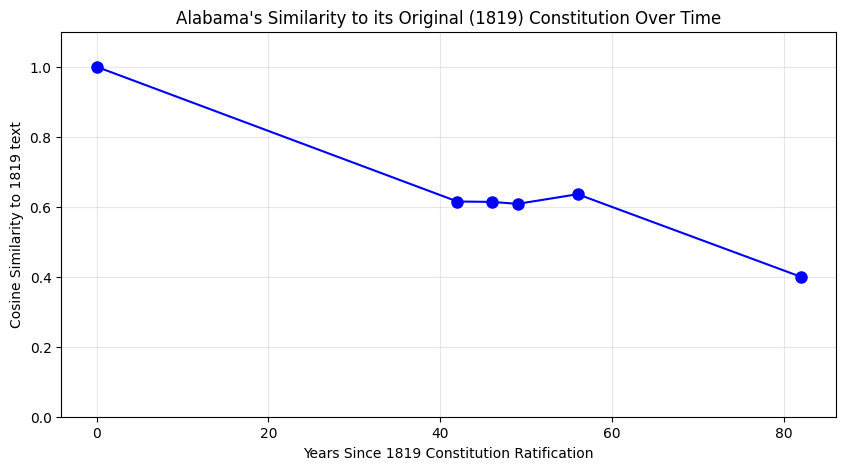

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a state with multiple constitutions to visualize
state_to_plot = 'Alabama'

# Ensure state_similarity_dfs dictionary is available from previous cells
if 'state_similarity_dfs' not in locals():
    print("Error: 'state_similarity_dfs' not found. Please run previous cells.")
elif state_to_plot in state_similarity_dfs:
    sim_df = state_similarity_dfs[state_to_plot]

    # 1. Heatmap of the state's evolution
    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_df, annot=True, cmap="YlGnBu", vmin=0.3, vmax=1.0, fmt=".2f")
    plt.title(f"{state_to_plot} Constitution Evolution (Similarity Heatmap)")
    plt.xlabel("Year")
    plt.ylabel("Year")
    plt.show()

    # 2. Line plot: Similarity to the FIRST constitution over time
    first_year = sim_df.index[0]
    evolution_series = sim_df.loc[first_year]

    # Calculate years since the first constitution
    years_since_first = [year - first_year for year in evolution_series.index]

    plt.figure(figsize=(10, 5))
    plt.plot(years_since_first, evolution_series.values, marker='o', linestyle='-', color='b', markersize=8)
    plt.title(f"{state_to_plot}'s Similarity to its Original ({first_year}) Constitution Over Time")
    plt.xlabel(f"Years Since {first_year} Constitution Ratification") # Updated x-axis label
    plt.ylabel(f"Cosine Similarity to {first_year} text")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Could not find {state_to_plot} in the dataset. Please ensure the state has multiple constitutional versions.")

## All 50 states

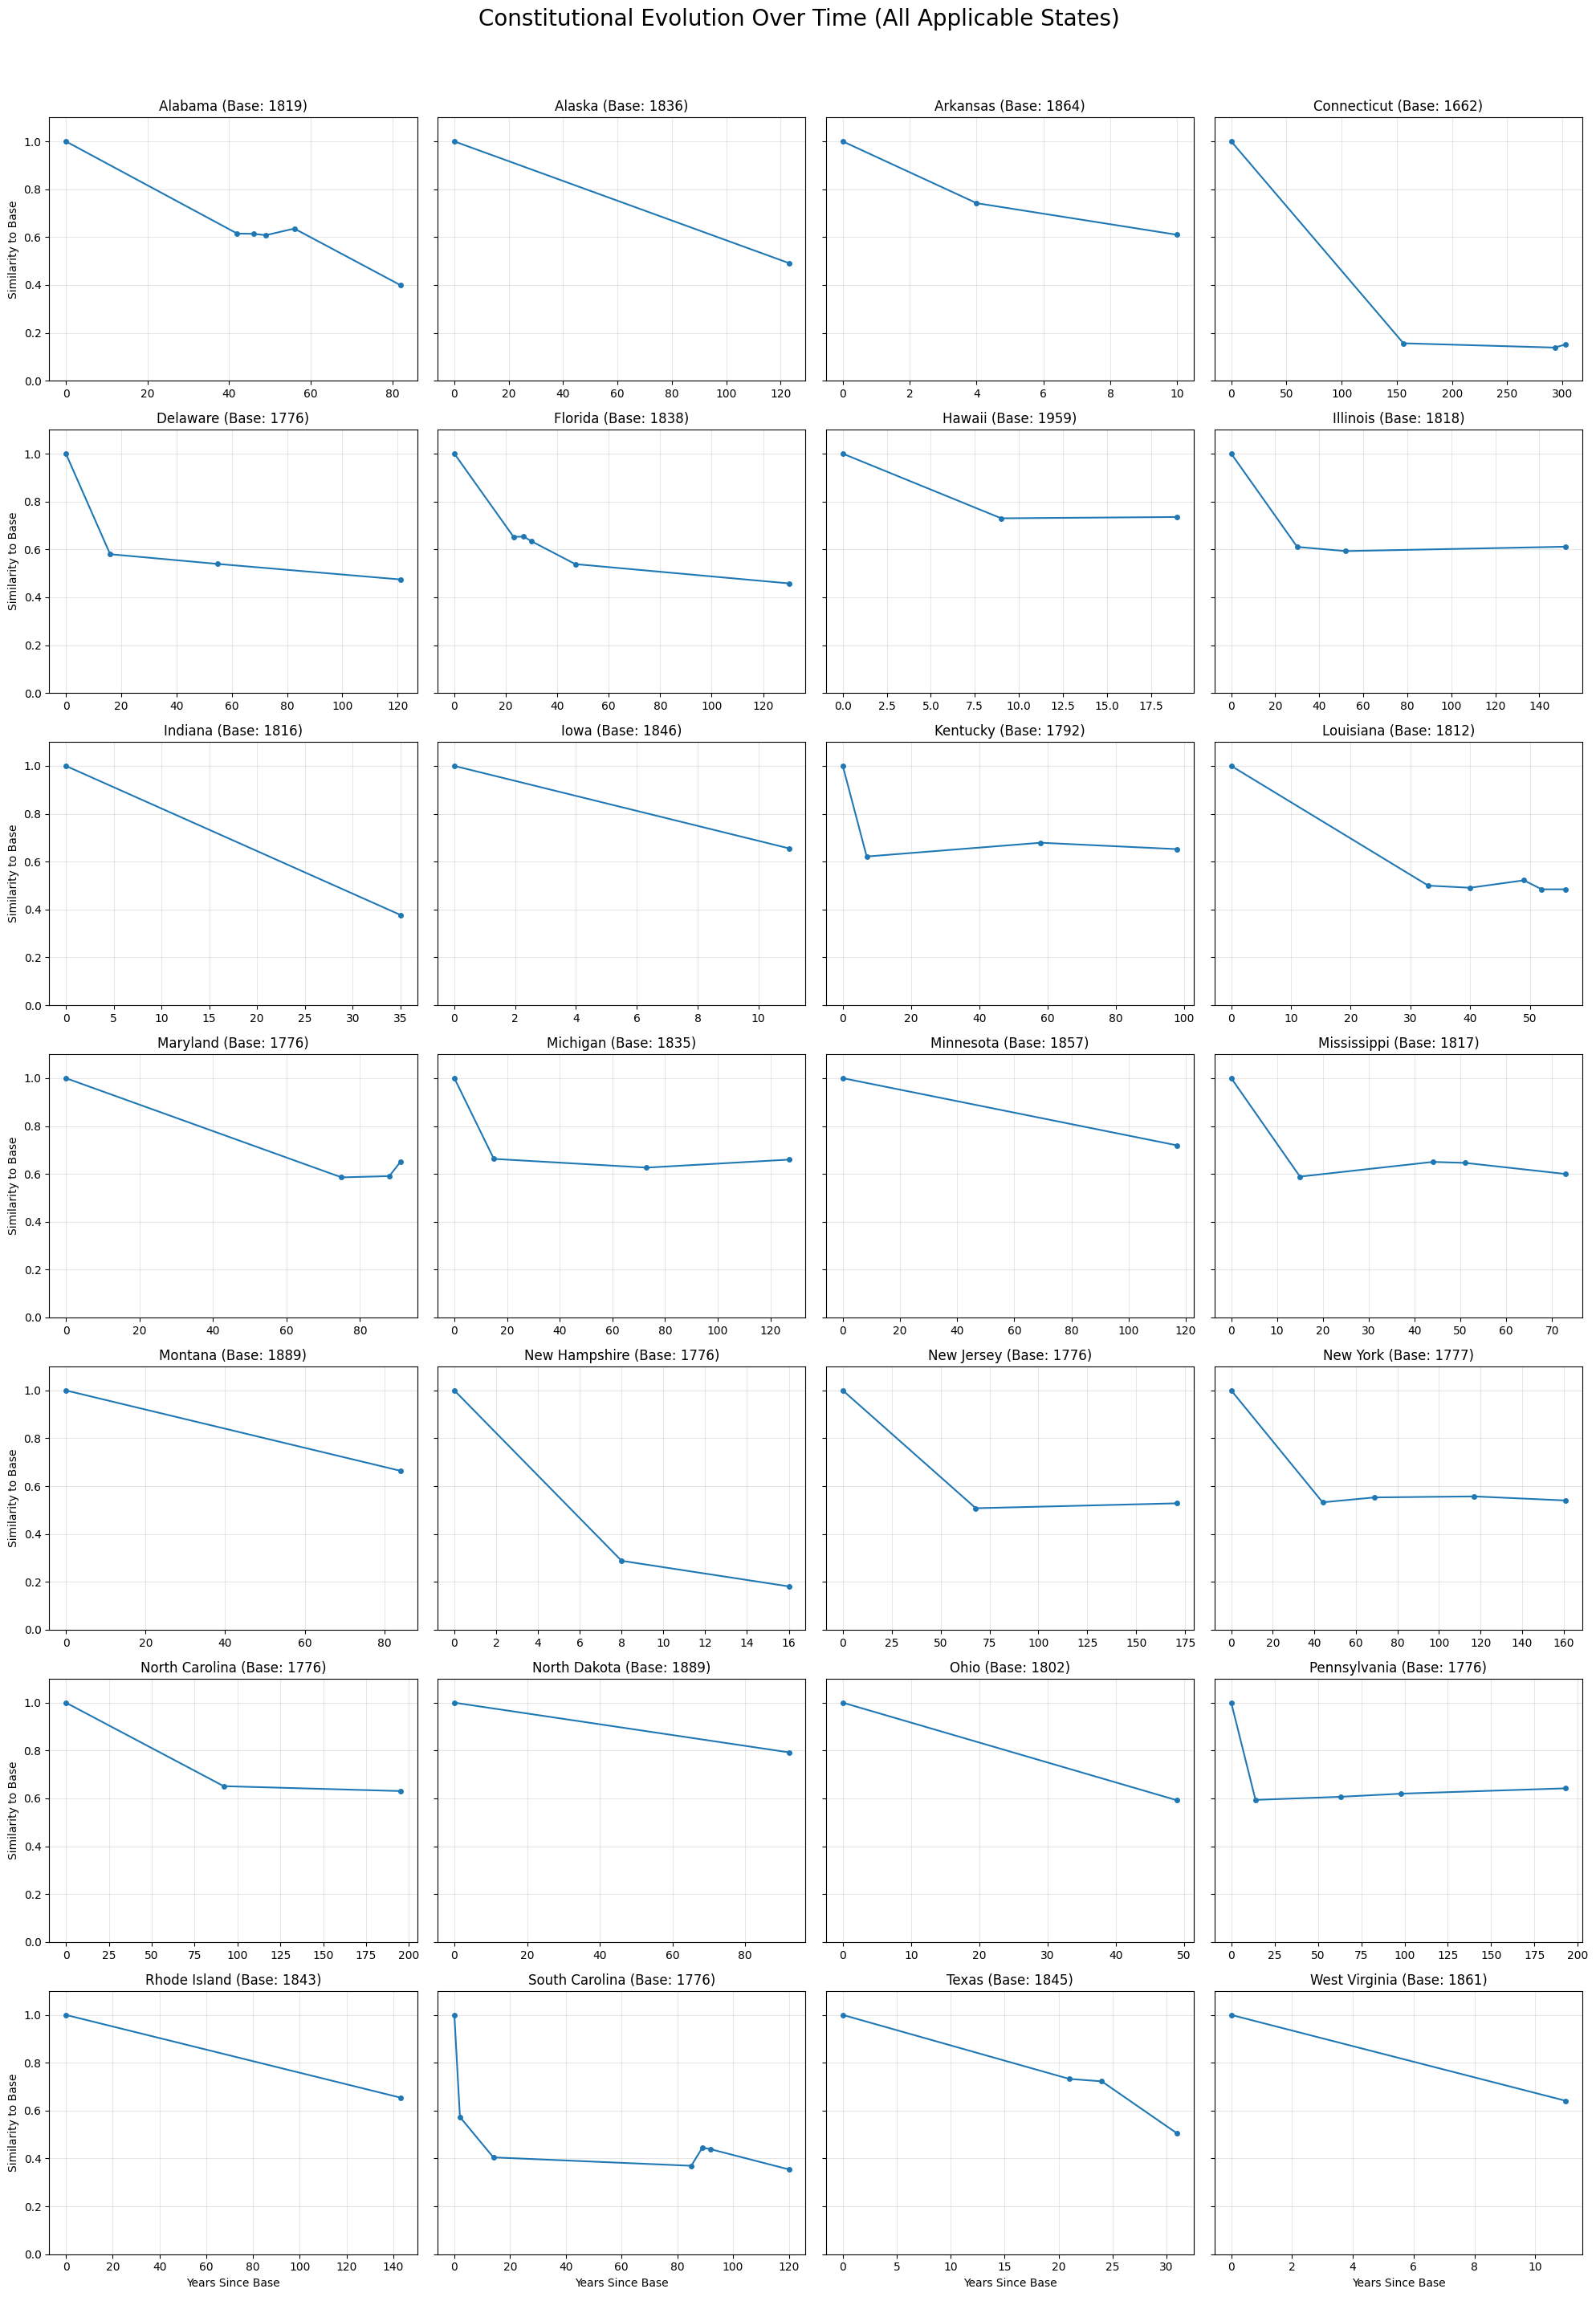

In [ ]:
import matplotlib.pyplot as plt
import math

# Get the list of states with multiple constitutions
states = list(state_similarity_dfs.keys())
num_states = len(states)

# Determine grid size (e.g., 4 columns)
cols = 4
rows = math.ceil(num_states / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), sharey=True)
axes = axes.flatten()

for i, state in enumerate(states):
    sim_df = state_similarity_dfs[state]
    first_year = sim_df.index[0]
    evolution_series = sim_df.loc[first_year]

    # Calculate years since the first constitution
    years_since_first = [year - first_year for year in evolution_series.index]

    ax = axes[i]
    ax.plot(years_since_first, evolution_series.values, marker='o', linestyle='-', markersize=4)
    ax.set_title(f"{state} (Base: {first_year})")
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

    # Add labels only to the outer plots to keep it clean
    if i % cols == 0:
        ax.set_ylabel("Similarity to Base")
    if i >= num_states - cols:
        ax.set_xlabel("Years Since Base")

# Hide any unused subplots
for j in range(num_states, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Constitutional Evolution Over Time (All Applicable States)", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


## Fastest Declining Constitutions
This analysis calculates the rate of decline (slope) using linear regression on each state's similarity to its base constitution over time. A more negative slope indicates a faster decline.

In [ ]:
import pandas as pd
from scipy.stats import linregress

decline_rates = []

for state, sim_df in state_similarity_dfs.items():
    first_year = sim_df.index[0]
    evolution_series = sim_df.loc[first_year]

    years_since_first = [year - first_year for year in evolution_series.index]
    similarities = evolution_series.values

    # Calculate the slope (rate of change) using linear regression
    slope, intercept, r_value, p_value, std_err = linregress(years_since_first, similarities)

    decline_rates.append({
        'State': state,
        'Slope (Decline/Year)': slope,
        'Decline per Decade': slope * 10,
        'Total Drop': 1.0 - similarities[-1],
        'Years Span': years_since_first[-1]
    })

# Create DataFrame and sort by the steepest negative slope
decline_df = pd.DataFrame(decline_rates)
decline_df = decline_df.sort_values(by='Slope (Decline/Year)', ascending=True).reset_index(drop=True)

print("States with the fastest decline in similarity to their base constitution:\n")
display(decline_df.head(10))

States with the fastest decline in similarity to their base constitution:



,State,Slope (Decline/Year),Decline per Decade,Total Drop,Years Span
0,New Hampshire,-0.051182,-0.511817,0.818908,16
1,Arkansas,-0.037678,-0.376778,0.390184,10
2,West Virginia,-0.032615,-0.326149,0.358764,11
3,Iowa,-0.031303,-0.313034,0.344337,11
4,Indiana,-0.017788,-0.177876,0.622565,35
5,Texas,-0.014737,-0.147369,0.495602,31
6,Hawaii,-0.013662,-0.136617,0.264644,19
7,Louisiana,-0.009197,-0.091971,0.515510,56
8,Ohio,-0.008331,-0.083311,0.408223,49
9,Alabama,-0.007138,-0.071384,0.600421,82


In [ ]:
display(decline_df.tail(10))

,State,Slope (Decline/Year),Decline per Decade,Total Drop,Years Span
18,New Jersey,-0.002519,-0.025190,0.471754,171
19,Rhode Island,-0.002416,-0.024162,0.345517,143
20,Minnesota,-0.002401,-0.024013,0.280948,117
21,North Dakota,-0.002256,-0.022556,0.207517,92
22,New York,-0.002235,-0.022348,0.459876,161
23,Kentucky,-0.001988,-0.019878,0.347766,98
24,Michigan,-0.001882,-0.018819,0.340391,127
25,North Carolina,-0.001860,-0.018604,0.369343,195
26,Illinois,-0.001736,-0.017358,0.388766,152
27,Pennsylvania,-0.000987,-0.009875,0.357884,193


### Total Decline

In [ ]:
total_decline_df = decline_df.sort_values(by='Total Drop', ascending=False).reset_index(drop=True)
display(total_decline_df.head(10))

,State,Slope (Decline/Year),Decline per Decade,Total Drop,Years Span
0,Connecticut,-0.002656,-0.026561,0.848216,303
1,New Hampshire,-0.051182,-0.511817,0.818908,16
2,South Carolina,-0.002987,-0.029871,0.645451,120
3,Indiana,-0.017788,-0.177876,0.622565,35
4,Alabama,-0.007138,-0.071384,0.600421,82
5,Florida,-0.003128,-0.031277,0.542007,130
6,Delaware,-0.003234,-0.032339,0.525632,121
7,Louisiana,-0.009197,-0.091971,0.515510,56
8,Alaska,-0.004131,-0.041312,0.508135,123
9,Texas,-0.014737,-0.147369,0.495602,31


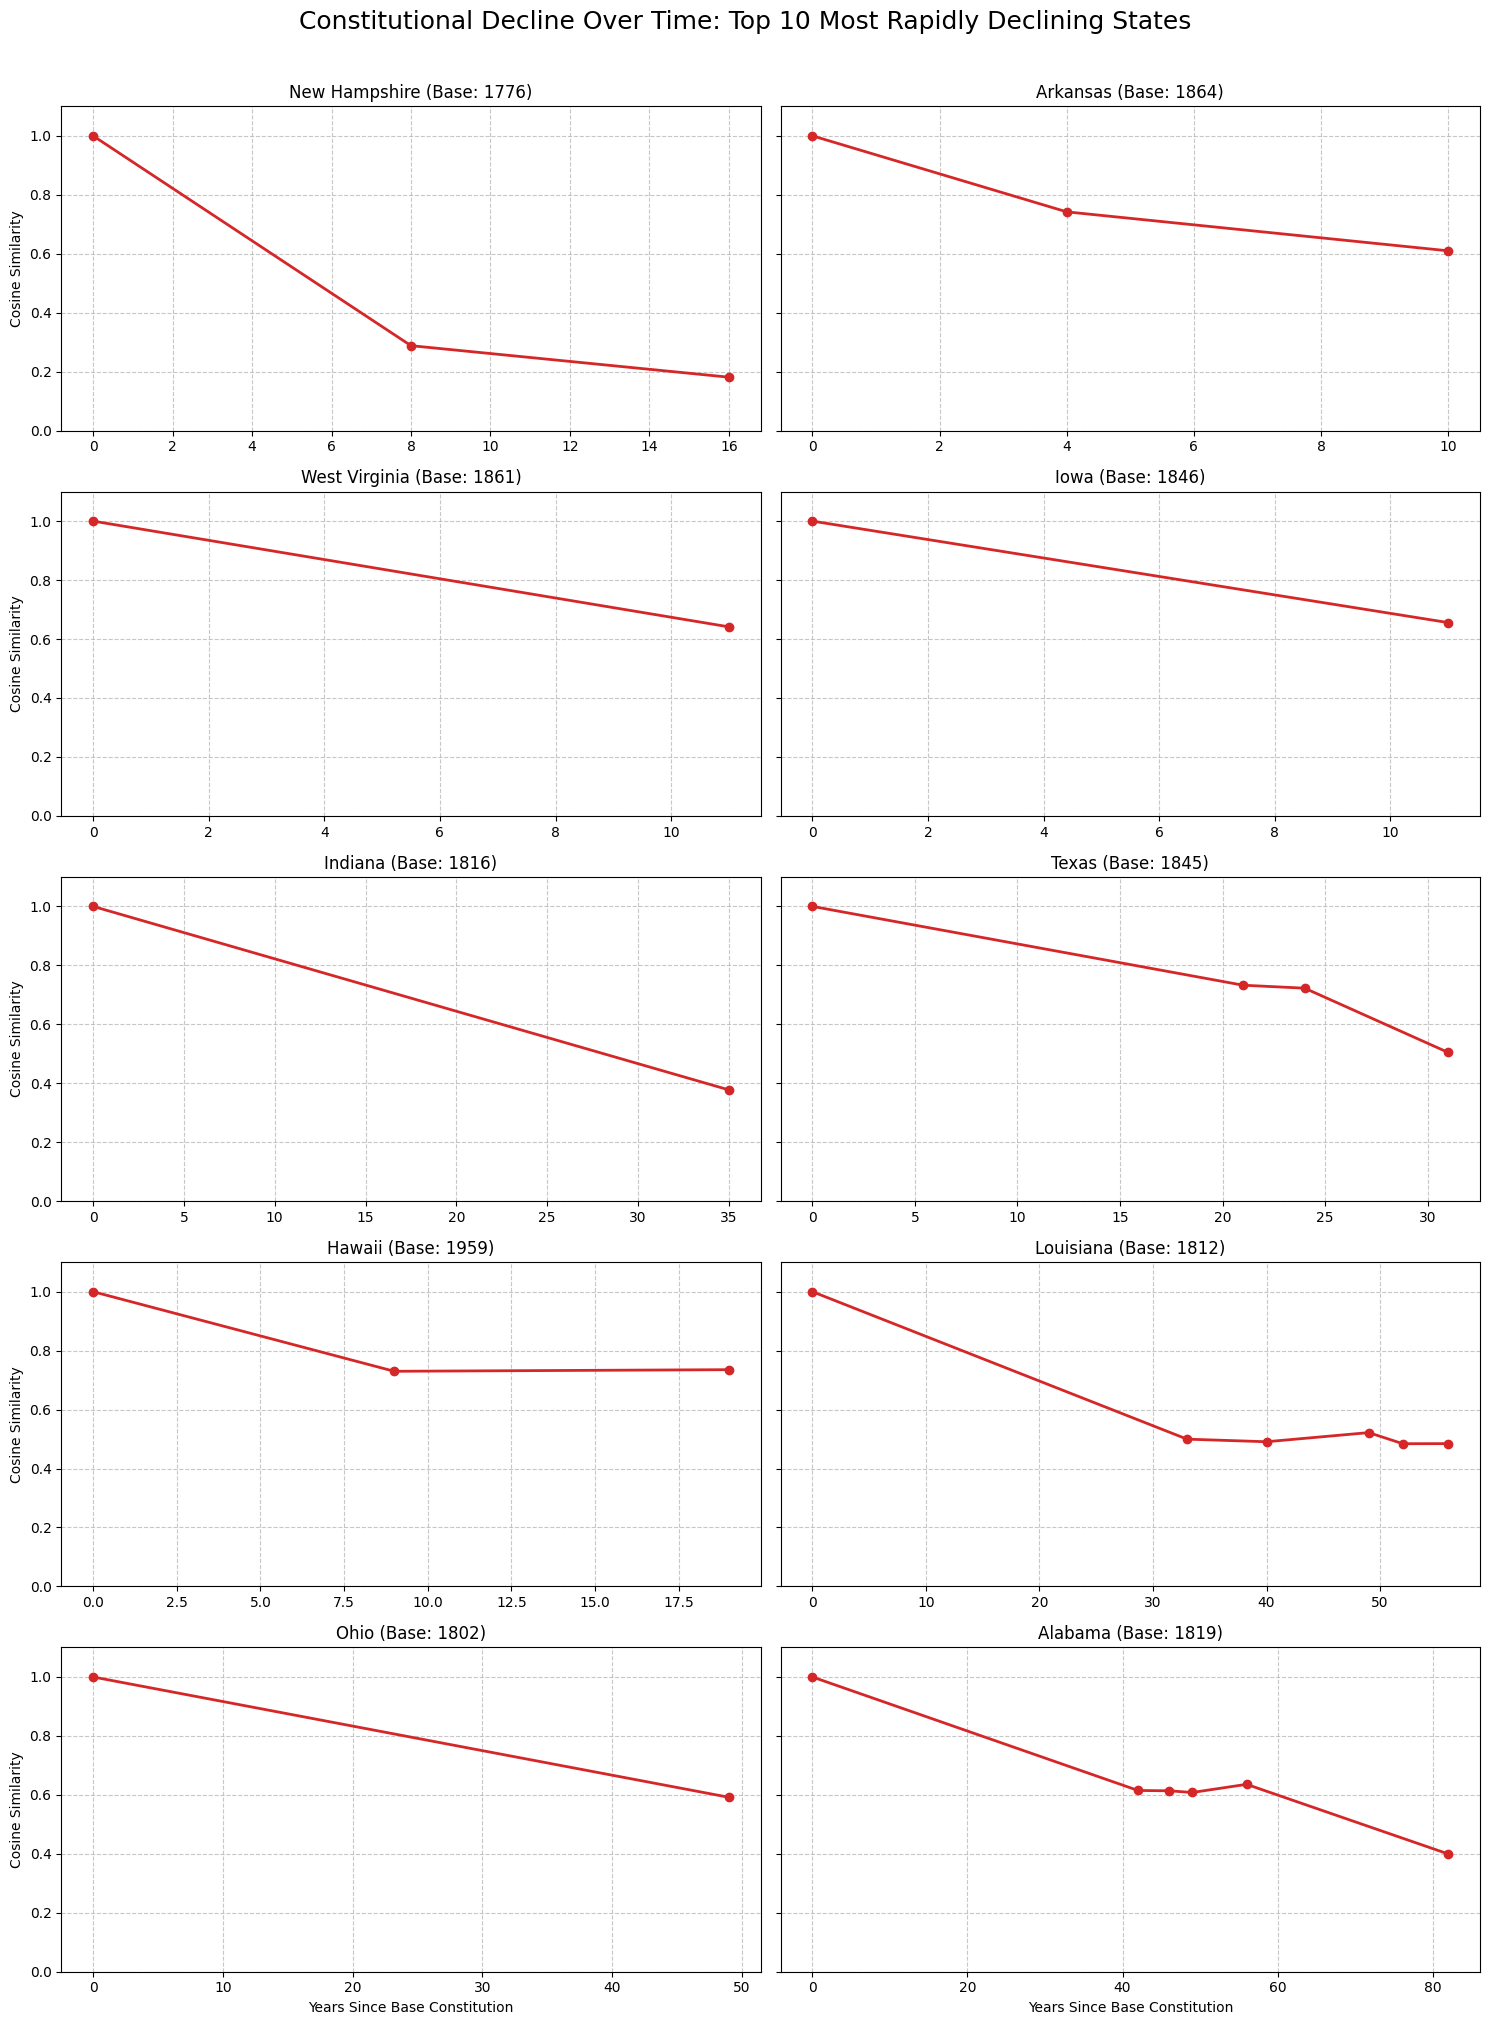

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the names of the top 10 most rapidly declining states
top_10_states = decline_df.head(10)['State'].tolist()

# Create a 5x2 grid of subplots
fig, axes = plt.subplots(5, 2, figsize=(15, 20), sharey=True)
axes = axes.flatten()

# Plot each state's trajectory on its own subplot
for i, state in enumerate(top_10_states):
    sim_df = state_similarity_dfs[state]
    first_year = sim_df.index[0]
    evolution_series = sim_df.loc[first_year]

    years_since_first = [year - first_year for year in evolution_series.index]

    ax = axes[i]
    ax.plot(years_since_first, evolution_series.values, marker='o', linestyle='-', linewidth=2, color='tab:red')
    ax.set_title(f"{state} (Base: {first_year})")
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Only add x-labels to the bottom row
    if i >= 8:
        ax.set_xlabel('Years Since Base Constitution')

    # Only add y-labels to the left column
    if i % 2 == 0:
        ax.set_ylabel('Cosine Similarity')

# Add an overall title
plt.suptitle('Constitutional Decline Over Time: Top 10 Most Rapidly Declining States', fontsize=18, y=1.01)

# Adjust layout and display
plt.tight_layout()
plt.show()

### Regional Trajectories Over Time
This chart aggregates the state-level trajectories into regional averages to show how different parts of the country evolved.

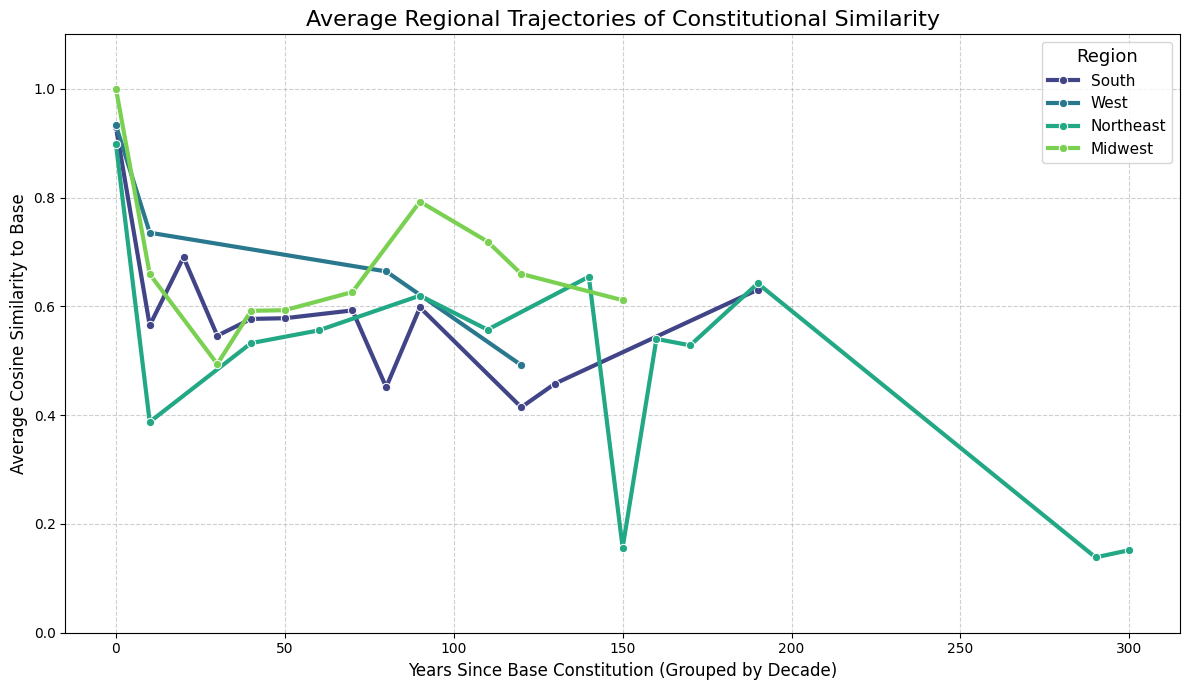

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the trajectory data for all states
traj_data = []
for state, sim_df in state_similarity_dfs.items():
    # Extract region for the current state
    region = df[df['State'] == state]['Region'].iloc[0]

    first_year = sim_df.index[0]
    evolution_series = sim_df.loc[first_year]

    for year in evolution_series.index:
        traj_data.append({
            'State': state,
            'Region': region,
            'Years Since Base': year - first_year,
            'Similarity': evolution_series.loc[year]
        })

traj_df = pd.DataFrame(traj_data)

# 2. Bin the years into decades to create smooth average lines for each region
traj_df['Decade Since Base'] = (traj_df['Years Since Base'] // 10) * 10

# 3. Plot the data
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=traj_df,
    x='Decade Since Base',
    y='Similarity',
    hue='Region',
    marker='o',
    errorbar=None,
    linewidth=3,
    palette='viridis'
)

plt.title('Average Regional Trajectories of Constitutional Similarity', fontsize=16)
plt.xlabel('Years Since Base Constitution (Grouped by Decade)', fontsize=12)
plt.ylabel('Average Cosine Similarity to Base', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Region', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Trajectories Over Time (Separate Plots)
This section breaks down the constitutional similarity trajectories into separate line graphs for each region.

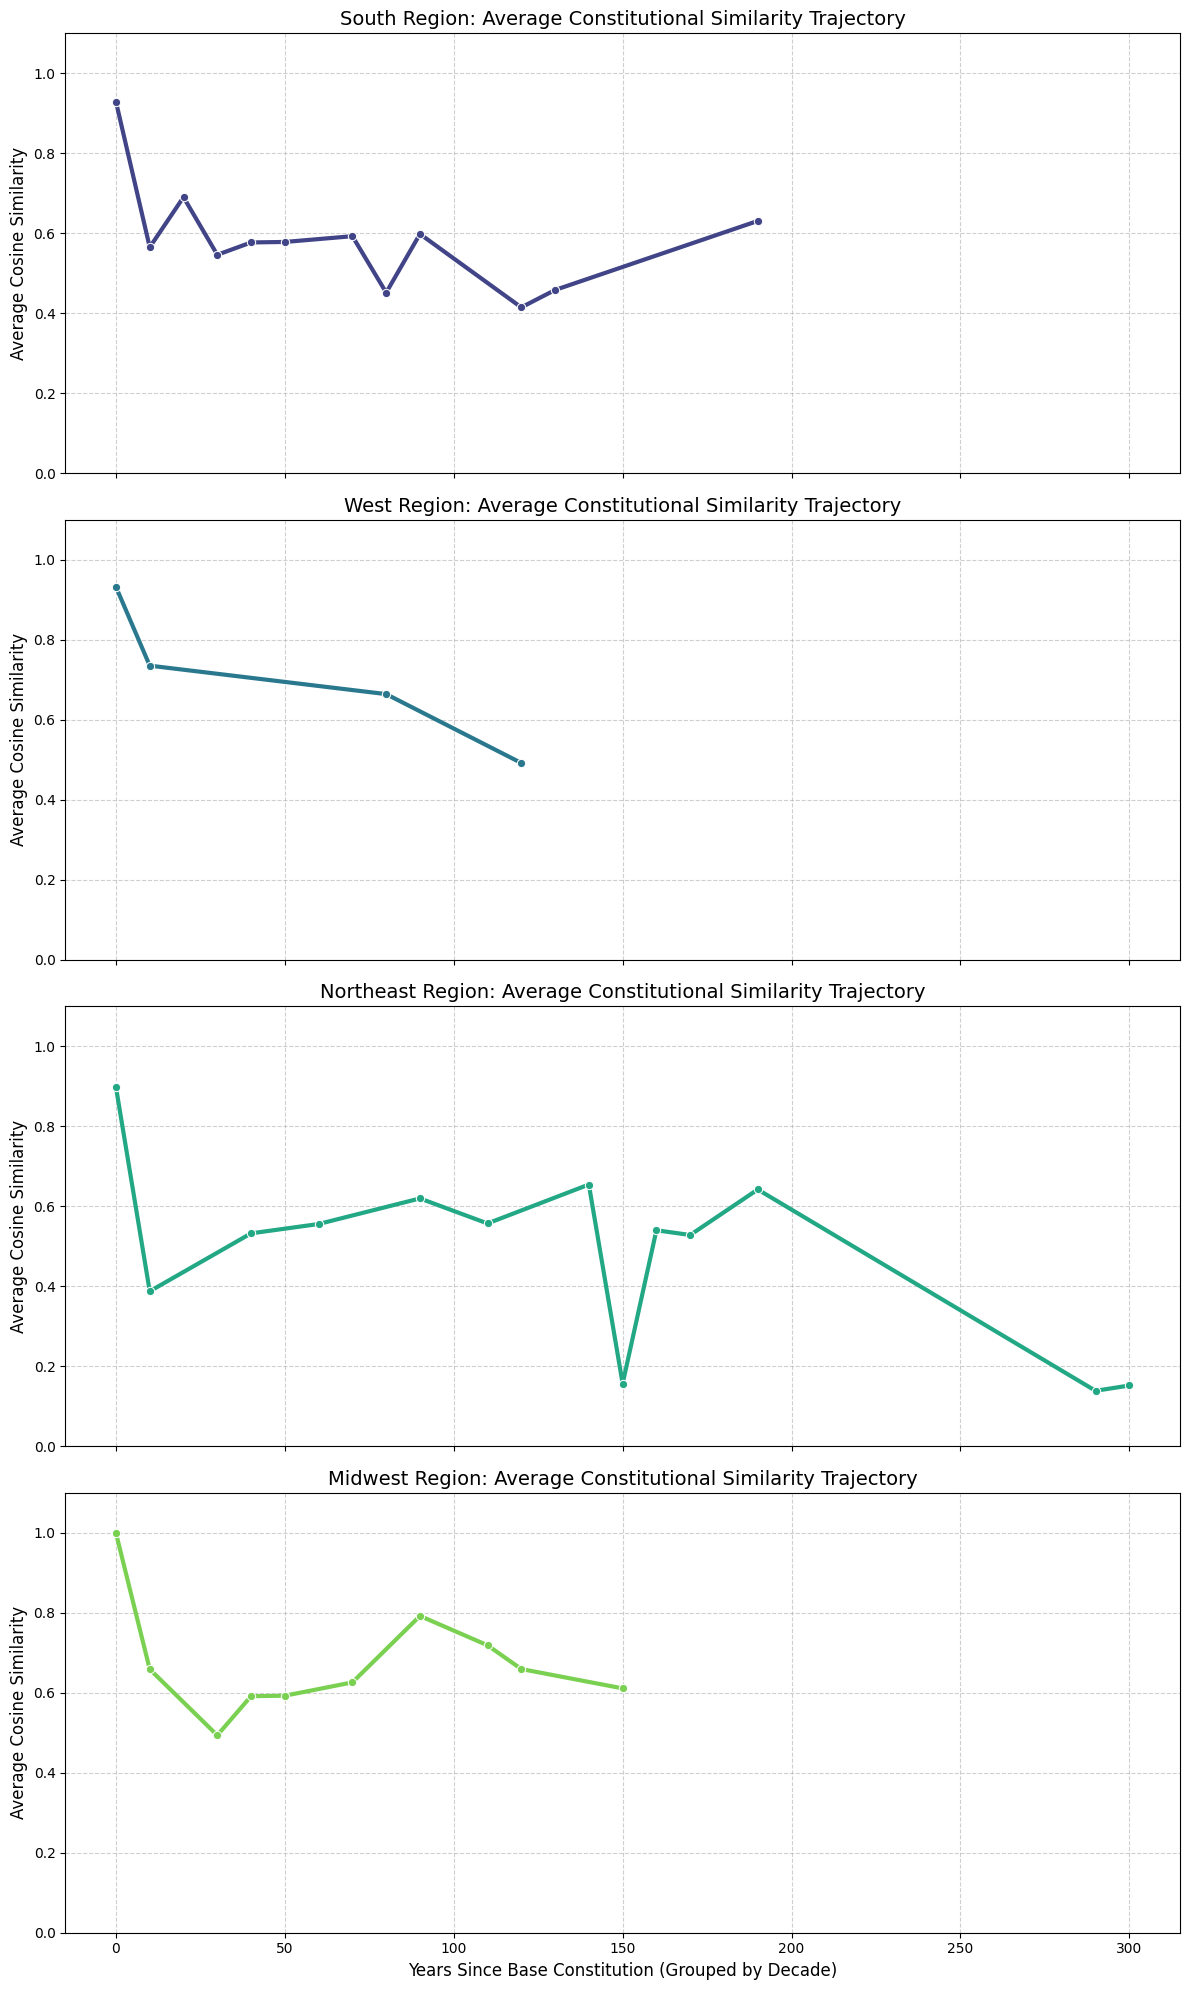

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming traj_df is already created from the previous cell

regions = traj_df['Region'].unique()
num_regions = len(regions)

fig, axes = plt.subplots(num_regions, 1, figsize=(12, 5 * num_regions), sharex=True)
if num_regions == 1:
    axes = [axes]

for i, region in enumerate(regions):
    ax = axes[i]
    region_data = traj_df[traj_df['Region'] == region]

    sns.lineplot(
        data=region_data,
        x='Decade Since Base',
        y='Similarity',
        marker='o',
        errorbar=None,
        linewidth=3,
        ax=ax,
        color=sns.color_palette('viridis', n_colors=num_regions)[i]
    )

    ax.set_title(f'{region} Region: Average Constitutional Similarity Trajectory', fontsize=14)
    ax.set_ylabel('Average Cosine Similarity', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Years Since Base Constitution (Grouped by Decade)', fontsize=12)
plt.tight_layout()
plt.show()

### Export Regional Plots as Images
This code generates individual image files (PNGs) for each region's trajectory and zips them for download.

In [ ]:
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Create a directory to store the regional plots
output_dir_regions = 'regional_plots'
os.makedirs(output_dir_regions, exist_ok=True)

regions = traj_df['Region'].unique()
num_regions = len(regions)
palette = sns.color_palette('viridis', n_colors=num_regions)

for i, region in enumerate(regions):
    plt.figure(figsize=(10, 6))
    region_data = traj_df[traj_df['Region'] == region]

    sns.lineplot(
        data=region_data,
        x='Decade Since Base',
        y='Similarity',
        marker='o',
        errorbar=None,
        linewidth=3,
        color=palette[i]
    )

    plt.title(f'{region} Region: Average Constitutional Similarity Trajectory', fontsize=14)
    plt.xlabel('Years Since Base Constitution (Grouped by Decade)', fontsize=12)
    plt.ylabel('Average Cosine Similarity', fontsize=12)
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save to file
    filename = os.path.join(output_dir_regions, f"{region}_trajectory.png")
    plt.savefig(filename, dpi=300) # Save as high-resolution PNG
    plt.close() # Close the figure to avoid displaying it again in the notebook

# Zip the directory
zip_filename_regions = f"{output_dir_regions}.zip"
shutil.make_archive(output_dir_regions, 'zip', output_dir_regions)

# Download the zip file
files.download(zip_filename_regions)

print(f"Successfully saved and zipped the regional plots as {zip_filename_regions}.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully saved and zipped the regional plots as regional_plots.zip.
